# Model Evaluation, Comparison, and Limitations

**Purpose.** Present every category's recorded detector and subtype-classifier metrics in one place and interpret them honestly.

**Expected result.** Advanced image/pixel metrics, portable detector metrics, subtype accuracy/macro-F1, and a clear list of categories that need further improvement.

**Platform connection.** These values populate model-monitoring views and support threshold/model-selection decisions; they are not generated from dashboard mock data.

In [1]:
from pathlib import Path
import json
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import JSON, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "ml").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def locate_mvtec_root() -> Path:
    configured = os.getenv("MVTEC_DATASET_ROOT")
    candidates = [
        Path(configured).expanduser() if configured else None,
        PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai-github" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection1",
    ]
    for candidate in candidates:
        if candidate and candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "MVTec AD was not found. Set MVTEC_DATASET_ROOT or place the dataset under "
        "data/raw/mvtec_anomaly_detection."
    )

DATASET_ROOT = locate_mvtec_root()
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def image_files(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted(path for path in directory.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)

def first_test_image(category: str, label: str) -> Path:
    paths = image_files(DATASET_ROOT / category / "test" / label)
    if not paths:
        raise FileNotFoundError(f"No {category}/{label} test image was found.")
    return paths[0]

def first_defect(category: str) -> tuple[str, Path]:
    test_root = DATASET_ROOT / category / "test"
    defect_dirs = sorted(path for path in test_root.iterdir() if path.is_dir() and path.name != "good")
    for directory in defect_dirs:
        paths = image_files(directory)
        if paths:
            return directory.name, paths[0]
    raise FileNotFoundError(f"No defective test image was found for {category}.")

def mask_path_for(category: str, label: str, image_path: Path) -> Path | None:
    if label == "good":
        return None
    candidate = DATASET_ROOT / category / "ground_truth" / label / f"{image_path.stem}_mask.png"
    return candidate if candidate.exists() else None

def read_rgb(path: Path) -> np.ndarray:
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Project root: {PROJECT_ROOT}")
print(f"MVTec root:  {DATASET_ROOT}")

Project root: C:\Users\HP\Desktop\springboard\VisionInspectAI-team
MVTec root:  C:\Users\HP\Desktop\springboard\visioninspect-ai-github\data\raw\mvtec_anomaly_detection


In [2]:
from ml.model_registry import SUPPORTED_CATEGORIES, category_model_spec

metric_rows = []
for category in SUPPORTED_CATEGORIES:
    spec = category_model_spec(category)
    metadata = json.loads(spec.metadata_path.read_text(encoding="utf-8"))
    advanced = metadata.get("metrics", {})
    advanced = advanced[0] if isinstance(advanced, list) and advanced else advanced
    portable = metadata.get("baseline_threshold_calibration", {})
    classifier = metadata.get("defect_classifier", {})
    metric_rows.append(
        {
            "category": category,
            "advanced_model": spec.model_kind,
            "advanced_image_AUROC": advanced.get("image_AUROC"),
            "advanced_image_F1": advanced.get("image_F1Score"),
            "advanced_pixel_AUROC": advanced.get("pixel_AUROC"),
            "advanced_pixel_F1": advanced.get("pixel_F1Score"),
            "portable_accuracy": portable.get("cv_accuracy", portable.get("holdout_accuracy")),
            "portable_recall": portable.get("cv_recall", portable.get("holdout_recall")),
            "portable_specificity": portable.get("cv_specificity", portable.get("holdout_specificity")),
            "portable_F1": portable.get("cv_f1", portable.get("holdout_f1")),
            "portable_AUROC": portable.get("auroc", portable.get("holdout_auroc")),
            "subtype_accuracy": classifier.get("accuracy"),
            "subtype_macro_F1": classifier.get("macro_f1"),
            "subtype_count": len(classifier.get("labels", [])),
        }
    )

metrics_df = pd.DataFrame(metric_rows)
metric_columns = [column for column in metrics_df.columns if column not in {"category", "advanced_model", "subtype_count"}]
display(metrics_df.style.format({column: "{:.4f}" for column in metric_columns}, na_rep="n/a"))

,category,advanced_model,advanced_image_AUROC,advanced_image_F1,advanced_pixel_AUROC,advanced_pixel_F1,portable_accuracy,portable_recall,portable_specificity,portable_F1,portable_AUROC,subtype_accuracy,subtype_macro_F1,subtype_count
0,bottle,padim,0.9968,0.9764,0.9820,0.7141,0.9639,0.9841,0.9000,0.9764,0.9913,0.8730,0.8719,3
1,cable,patchcore,0.9695,0.9274,0.9815,0.6147,0.7933,0.7717,0.8276,0.8208,0.8711,0.8587,0.8529,8
2,capsule,padim,0.8991,0.9554,0.9848,0.4267,0.7955,0.8165,0.6957,0.8683,0.8396,0.8182,0.8250,5
3,carpet,padim,0.9952,0.9724,0.9896,0.5656,0.5641,0.4719,0.8571,0.6222,0.7885,0.8989,0.9009,5
4,grid,padim,0.9524,0.9298,0.9699,0.4019,0.5769,0.5614,0.6190,0.6598,0.5940,0.7719,0.7742,5
5,hazelnut,patchcore,0.9950,0.9640,0.9881,0.6424,0.8545,0.8143,0.9250,0.8769,0.9414,0.9286,0.9295,4
6,leather,padim,1.0000,0.9945,0.9897,0.3675,0.8145,0.7717,0.9375,0.8606,0.8845,0.9022,0.9017,5
7,metal_nut,padim,0.9839,0.9735,0.9679,0.7619,0.6957,0.6559,0.8636,0.7771,0.8060,0.9355,0.9357,4
8,pill,padim,0.8882,0.9459,0.9588,0.5451,0.5808,0.5745,0.6154,0.6983,0.7444,0.8723,0.8828,7
9,screw,patchcore,0.9650,0.9407,0.9918,0.3717,0.7375,0.7395,0.7317,0.8073,0.8350,0.9244,0.9233,5


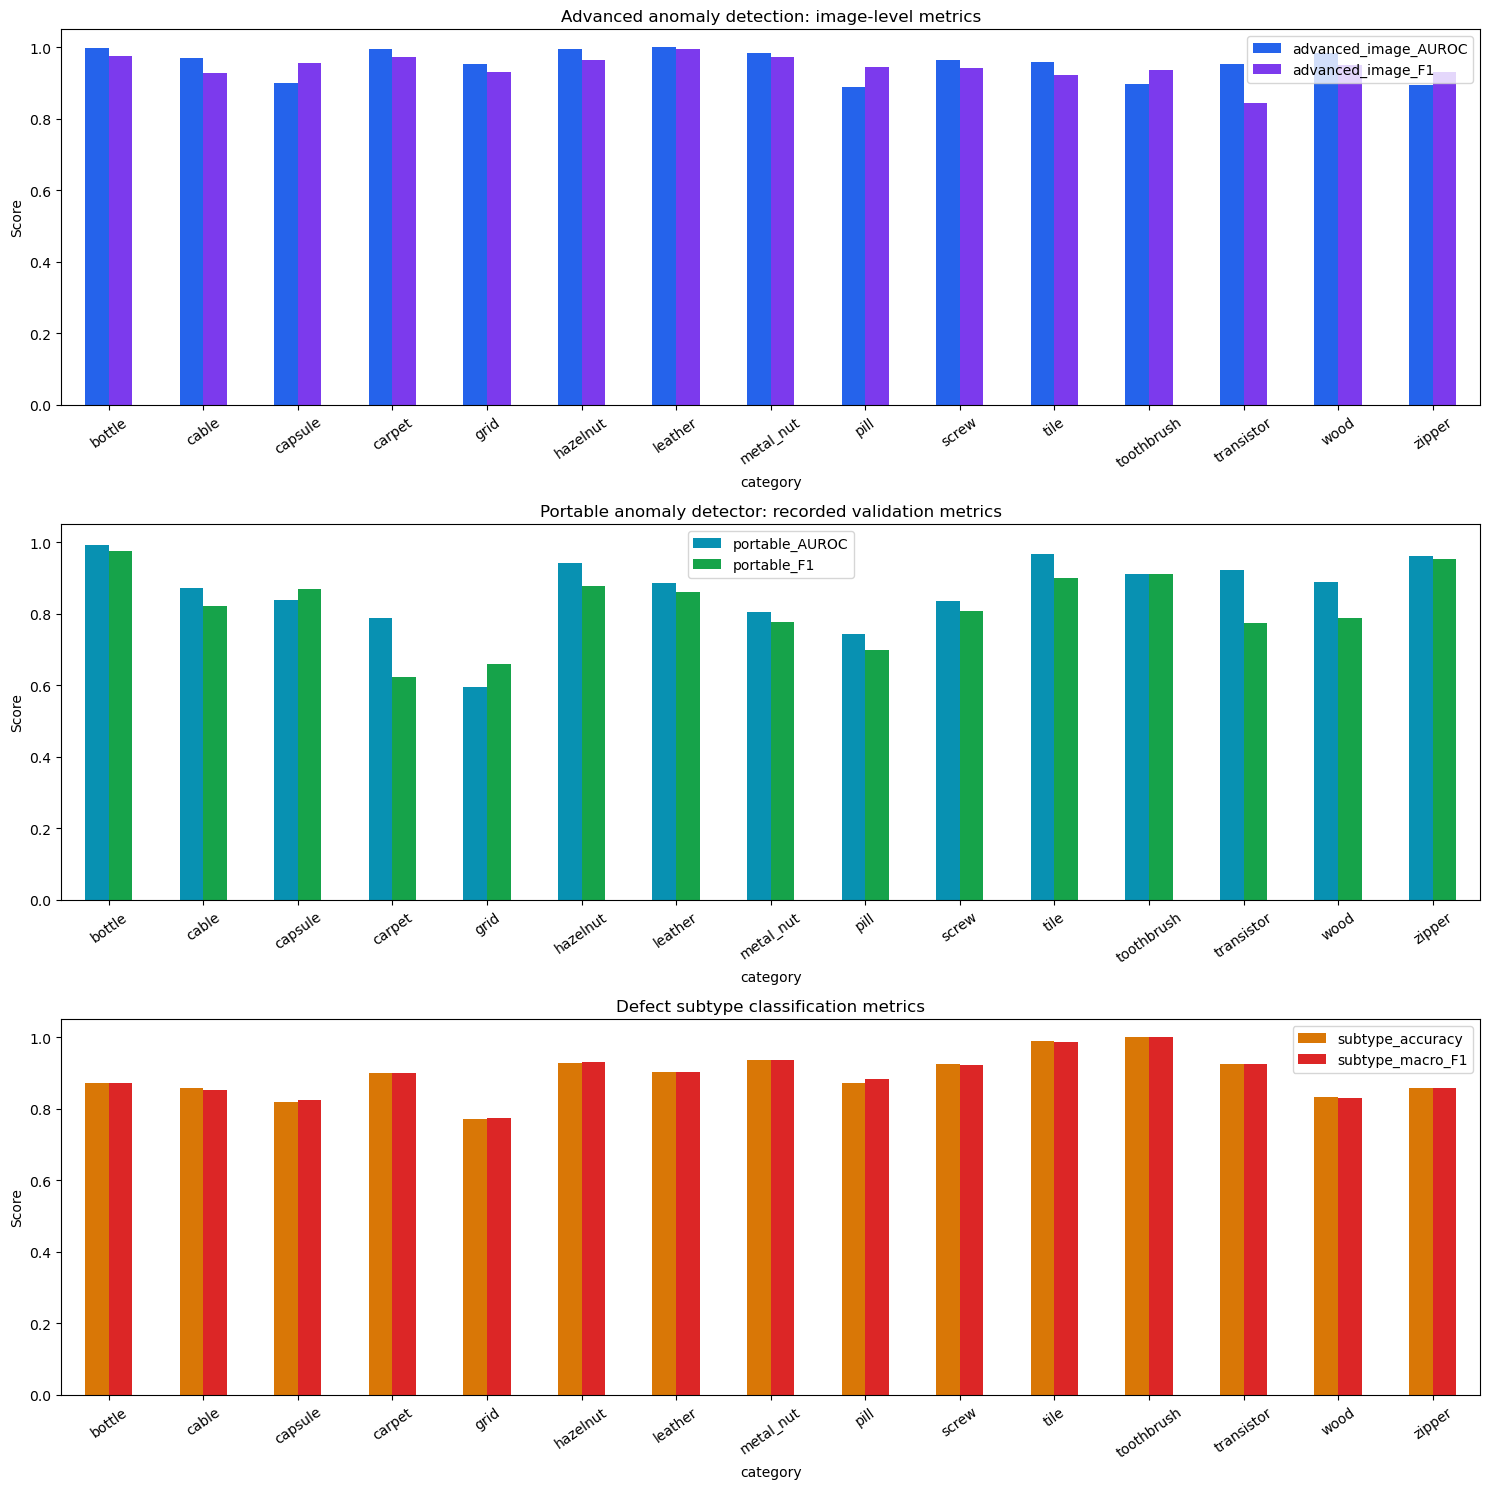

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(15, 15))
metrics_df.set_index("category")[["advanced_image_AUROC", "advanced_image_F1"]].plot(kind="bar", ax=axes[0], color=["#2563eb", "#7c3aed"])
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Advanced anomaly detection: image-level metrics")
metrics_df.set_index("category")[["portable_AUROC", "portable_F1"]].plot(kind="bar", ax=axes[1], color=["#0891b2", "#16a34a"])
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Portable anomaly detector: recorded validation metrics")
metrics_df.set_index("category")[["subtype_accuracy", "subtype_macro_F1"]].plot(kind="bar", ax=axes[2], color=["#d97706", "#dc2626"])
axes[2].set_ylim(0, 1.05)
axes[2].set_title("Defect subtype classification metrics")
for axis in axes:
    axis.set_ylabel("Score")
    axis.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

In [4]:
attention_rows = []
for row in metrics_df.to_dict(orient="records"):
    issues = []
    if pd.notna(row["portable_F1"]) and row["portable_F1"] < 0.85:
        issues.append("portable detector F1 below 0.85")
    if pd.notna(row["subtype_macro_F1"]) and row["subtype_macro_F1"] < 0.85:
        issues.append("subtype macro-F1 below 0.85")
    if pd.notna(row["advanced_pixel_F1"]) and row["advanced_pixel_F1"] < 0.50:
        issues.append("pixel F1 below 0.50")
    if row["subtype_count"] <= 1:
        issues.append("single known defect subtype; multiclass score is not informative")
    if issues:
        attention_rows.append({"category": row["category"], "review_needed": "; ".join(issues)})

display(pd.DataFrame(attention_rows))

,category,review_needed
0,cable,portable detector F1 below 0.85
1,capsule,subtype macro-F1 below 0.85; pixel F1 below 0.50
2,carpet,portable detector F1 below 0.85
3,grid,portable detector F1 below 0.85; subtype macro...
4,leather,pixel F1 below 0.50
5,metal_nut,portable detector F1 below 0.85
6,pill,portable detector F1 below 0.85
7,screw,portable detector F1 below 0.85; pixel F1 belo...
8,toothbrush,single known defect subtype; multiclass score ...
9,transistor,portable detector F1 below 0.85


## Metric definitions

- **Accuracy:** fraction of all predictions that are correct. It can hide minority-class failures.
- **Precision:** fraction of predicted defects that are truly defective.
- **Recall:** fraction of actual defects detected; especially important for quality inspection.
- **Specificity:** fraction of normal products correctly accepted.
- **F1:** harmonic mean of precision and recall.
- **Macro-F1:** average F1 across subtype classes, giving each subtype equal weight.
- **AUROC:** ranking quality over all possible decision thresholds.
- **Pixel F1/AUROC:** overlap/ranking quality at the localization-map level, not image classification.

## Current limitations

1. Categories do not all exceed 0.85 on every metric; the table identifies where more data, alignment, resolution, model tuning, or calibration is needed.
2. MVTec labels are benchmark defect names, not a universal industrial defect taxonomy.
3. Subtype training uses labelled test folders because official MVTec training folders contain only normal images. These subtype metrics must therefore be described as project-specific validation.
4. `toothbrush` has one labelled defect subtype, so its perfect subtype score does not demonstrate multiclass discrimination.
5. Pixel F1 is threshold-sensitive and often lower than image AUROC even when the detector correctly identifies a defective image.
6. A real production rollout would require factory-specific images, camera calibration, product-specific critical zones, drift monitoring, and acceptance testing.

## What this demonstrates

The evaluation does not collapse all tasks into one “accuracy” number. It separately measures image anomaly detection, pixel localization, and subtype classification, preserving the limitations and protocol attached to each artifact.